# agentv16_async_parallel_graph

Revised v16: async plus parallel graph branches.


Graph:

```text
              ┌→ async_fetch_metrics ┐
START → planner                        ├→ summarize → END
              └→ async_fetch_logs    ┘
```

The two fetch nodes should overlap in LangSmith timestamps.


In [1]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


In [2]:
from typing import NotRequired, TypedDict

class AgentState(TypedDict):
    input: str
    plan: NotRequired[str]
    metrics_result: NotRequired[str]
    logs_result: NotRequired[str]
    metrics_started_at: NotRequired[float]
    metrics_finished_at: NotRequired[float]
    logs_started_at: NotRequired[float]
    logs_finished_at: NotRequired[float]
    final_answer: NotRequired[str]


In [3]:
import asyncio
import time

async def planner_node(state: AgentState) -> AgentState:
    await asyncio.sleep(0.1)
    return {"plan": "Collect metrics and logs in parallel, then synthesize cause and next action."}

async def fetch_cloudwatch_metrics() -> str:
    await asyncio.sleep(2.0)
    return "Metrics: CHECK-DOMAIN p95 response_time increased to 240 ms after R13; timeout volume increased for client_b."

async def fetch_cloudwatch_logs() -> str:
    await asyncio.sleep(3.0)
    return "Logs: repeated CONNECTION_TIMEOUT events for upstream registry endpoint during peak traffic windows."


In [4]:
async def async_fetch_metrics_node(state: AgentState) -> AgentState:
    started = time.perf_counter()
    result = await fetch_cloudwatch_metrics()
    finished = time.perf_counter()
    return {"metrics_result": result, "metrics_started_at": started, "metrics_finished_at": finished}

async def async_fetch_logs_node(state: AgentState) -> AgentState:
    started = time.perf_counter()
    result = await fetch_cloudwatch_logs()
    finished = time.perf_counter()
    return {"logs_result": result, "logs_started_at": started, "logs_finished_at": finished}


In [5]:
from langchain_openai import ChatOpenAI

async def summarize_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    metrics_duration = state["metrics_finished_at"] - state["metrics_started_at"]
    logs_duration = state["logs_finished_at"] - state["logs_started_at"]
    prompt = f'''
User request:
{state["input"]}

Plan:
{state["plan"]}

Metrics:
{state["metrics_result"]}

Logs:
{state["logs_result"]}

Timing:
metrics duration = {metrics_duration:.2f} seconds
logs duration = {logs_duration:.2f} seconds

Write a concise incident analysis with likely cause and next action.
'''
    response = await llm.ainvoke(prompt)
    return {"final_answer": response.content}


In [6]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    g = StateGraph(AgentState)
    g.add_node("planner", planner_node)
    g.add_node("async_fetch_metrics", async_fetch_metrics_node)
    g.add_node("async_fetch_logs", async_fetch_logs_node)
    g.add_node("summarize", summarize_node)

    g.add_edge(START, "planner")
    g.add_edge("planner", "async_fetch_metrics")
    g.add_edge("planner", "async_fetch_logs")
    g.add_edge("async_fetch_metrics", "summarize")
    g.add_edge("async_fetch_logs", "summarize")
    g.add_edge("summarize", END)

    return g.compile()

graph = build_graph()


In [7]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	async_fetch_metrics(async_fetch_metrics)
	async_fetch_logs(async_fetch_logs)
	summarize(summarize)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	async_fetch_logs --> summarize;
	async_fetch_metrics --> summarize;
	planner --> async_fetch_logs;
	planner --> async_fetch_metrics;
	summarize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



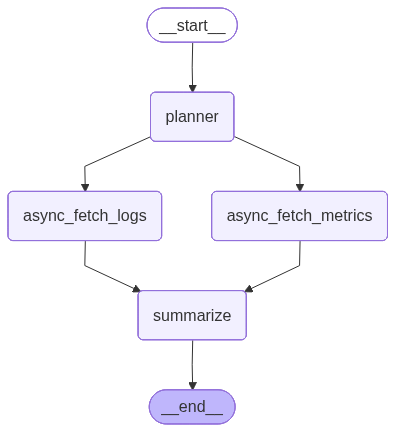

In [8]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed:", e)


In [9]:
start = time.perf_counter()

result = await graph.ainvoke({
    "input": "Investigate EPP CHECK-DOMAIN latency after release R13."
})

elapsed = time.perf_counter() - start
print("Elapsed seconds:", round(elapsed, 2))
print("Metrics duration:", round(result["metrics_finished_at"] - result["metrics_started_at"], 2))
print("Logs duration:", round(result["logs_finished_at"] - result["logs_started_at"], 2))
print()
print(result["final_answer"])


Elapsed seconds: 9.66
Metrics duration: 2.0
Logs duration: 3.0

### Incident Analysis: EPP CHECK-DOMAIN Latency Post R13 Release

**Overview:**
Following the release of R13, we observed a significant increase in latency for the EPP CHECK-DOMAIN operation, with the p95 response time rising to 240 ms. Additionally, there was a notable increase in timeout volume for client_b.

**Metrics:**
- **p95 Response Time:** Increased to 240 ms post-R13.
- **Timeout Volume:** Increased specifically for client_b.

**Logs:**
- **Key Findings:** Repeated CONNECTION_TIMEOUT events were logged for the upstream registry endpoint during peak traffic windows, indicating that the system was unable to establish connections within the expected timeframe.

**Timing:**
- **Metrics Collection Duration:** 2.00 seconds
- **Logs Collection Duration:** 3.00 seconds

**Likely Cause:**
The increase in latency and timeout events can be attributed to the changes introduced in R13, which may have affected the efficiency o

In [10]:
overlap = min(result["metrics_finished_at"], result["logs_finished_at"]) - max(result["metrics_started_at"], result["logs_started_at"])

print("Metrics started:", result["metrics_started_at"])
print("Metrics ended:  ", result["metrics_finished_at"])
print("Logs started:   ", result["logs_started_at"])
print("Logs ended:     ", result["logs_finished_at"])
print("Overlap seconds:", round(max(0, overlap), 2))


Metrics started: 16613.60201089
Metrics ended:   16615.604132161
Logs started:    16613.601982965
Logs ended:      16616.603086045
Overlap seconds: 2.0


In [11]:
async for chunk in graph.astream(
    {"input": "Investigate EPP CHECK-DOMAIN latency after release R13."},
    stream_mode="updates",
):
    print("\n--- async update ---")
    print(chunk)



--- async update ---
{'planner': {'plan': 'Collect metrics and logs in parallel, then synthesize cause and next action.'}}

--- async update ---
{'async_fetch_metrics': {'metrics_result': 'Metrics: CHECK-DOMAIN p95 response_time increased to 240 ms after R13; timeout volume increased for client_b.', 'metrics_started_at': 16647.031808888, 'metrics_finished_at': 16649.033107033}}

--- async update ---
{'async_fetch_logs': {'logs_result': 'Logs: repeated CONNECTION_TIMEOUT events for upstream registry endpoint during peak traffic windows.', 'logs_started_at': 16647.031798781, 'logs_finished_at': 16650.033102581}}

--- async update ---
{'summarize': {'final_answer': "### Incident Analysis: EPP CHECK-DOMAIN Latency Post R13 Release\n\n**Overview:**\nFollowing the release of R13, we observed a significant increase in latency for the EPP CHECK-DOMAIN operation, with the p95 response time rising to 240 ms. Additionally, there was a notable increase in timeout volume for client_b, correlating 

LangSmith check:

`async_fetch_metrics` and `async_fetch_logs` should overlap.

`summarize` should start only after both finish.
